# Imports and Configuration

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
import cv2 
import pywt # For Wavelet Transform
import timm # For the ViT backbone
import matplotlib.pyplot as plt

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters aligned with Battocchio et al. and Corvi et al.
NUM_FRAMES = 8       # Temporal batch size
IMG_SIZE = 224       # Standard ViT input size
BATCH_SIZE = 16
LEARNING_RATE = 1e-4

Using device: cuda


# Wavelet Augmentation Function


In [13]:
def wavelet_blend(fake_frame, real_frame):
    """
    Applies Haar Wavelet decomposition and replaces the low-frequency 
    and H/V high-frequency components of 'fake_frame' with those from 'real_frame'.
    Keeps only the Diagonal details (cD) of the fake frame.
    """
    # Make sure tensors are on CPU and convert them to numpy
    # [C, H, W] -> [H, W, C]
    fake_np = fake_frame.detach().cpu().numpy().transpose(1, 2, 0) 
    real_np = real_frame.detach().cpu().numpy().transpose(1, 2, 0)
    
    aug_frame = np.zeros_like(fake_np)
    
    # Iterate over channels (RGB)
    for ch in range(3): 
        # 1-level decomposition (Haar)
        coeffs_fake = pywt.dwt2(fake_np[:,:,ch], 'haar')
        coeffs_real = pywt.dwt2(real_np[:,:,ch], 'haar')
        
        # cA = Approximation (Low frequencies)
        # cH = Horizontal details
        # cV = Vertical details
        # cD = Diagonal details (the ones we want to keep from the Fake!)
        cA_fake, (cH_fake, cV_fake, cD_fake) = coeffs_fake
        cA_real, (cH_real, cV_real, cD_real) = coeffs_real
        
        # MIXING STRATEGY:
        # Keep cD (Diagonal) from the FAKE (contains typical checkerboard artifacts)
        # Replace everything else with the REAL (removes semantic bias)
        new_coeffs = (cA_real, (cH_real, cV_real, cD_fake)) 
        
        # Reconstruction
        rec = pywt.idwt2(new_coeffs, 'haar')
        
        # Handle odd dimensions (idwt2 may be off by 1 pixel if input size is odd)
        # Coerce the shape to match the input
        h, w = fake_np.shape[:2]
        aug_frame[:,:,ch] = rec[:h, :w]
        
    # Safety clip: Bring values back to the [0, 1] range
    aug_frame = np.clip(aug_frame, 0.0, 1.0)
        
    # Return float32 tensor [C, H, W]
    return torch.from_numpy(aug_frame.transpose(2, 0, 1)).float()


In [ ]:
# Forensic-Oriented Augmentation (from "Seeing What Matters")
import io
from PIL import Image

class ForensicAugmentation:
    """
    Implements the 5 forensic augmentations proposed in the paper
    to improve detector robustness against post-processing
    """
    def __init__(self):
        self.jpeg_qualities = [70, 75, 80, 85, 90, 95]
        self.blur_kernels = [(3,3), (5,5), (7,7)]
        self.noise_levels = [0.01, 0.02, 0.03, 0.05]
        self.resize_factors = [0.7, 0.8, 0.9, 1.1, 1.2]
        
    def jpeg_compression(self, frame):
        """Simulate JPEG compression with random quality"""
        quality = int(np.random.choice(self.jpeg_qualities))  
        # Convert tensor [C,H,W] to numpy [H,W,C]
        frame_np = (frame.cpu().numpy().transpose(1,2,0) * 255).astype(np.uint8)
        
        # Simulate JPEG encode/decode
        pil_img = Image.fromarray(frame_np)
        buffer = io.BytesIO()
        pil_img.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)
        compressed = Image.open(buffer)
        
        # Return as tensor
        result = np.array(compressed).astype(np.float32) / 255.0
        return torch.from_numpy(result.transpose(2,0,1)).float()
    
    def gaussian_blur(self, frame):
        """Apply Gaussian blur"""
        kernel = int(np.random.choice([3, 5, 7])) 
        frame_np = frame.cpu().numpy().transpose(1,2,0)
        blurred = cv2.GaussianBlur(frame_np, (kernel, kernel), 0)
        return torch.from_numpy(blurred.transpose(2,0,1)).float()
    
    def gaussian_noise(self, frame):
        """Add Gaussian noise"""
        noise_level = float(np.random.choice(self.noise_levels)) 
        noise = torch.randn_like(frame) * noise_level
        return torch.clamp(frame + noise, 0, 1)
    
    def resize_artifact(self, frame):
        """Simulate resizing with quality loss"""
        factor = float(np.random.choice(self.resize_factors)) 
        h, w = frame.shape[1], frame.shape[2]
        new_h, new_w = int(h * factor), int(w * factor)
        
        frame_np = frame.cpu().numpy().transpose(1,2,0)
        resized = cv2.resize(frame_np, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
        restored = cv2.resize(resized, (w, h), interpolation=cv2.INTER_LINEAR)
        
        return torch.from_numpy(restored.transpose(2,0,1)).float()
    
    def color_jitter(self, frame):
        """Alter brightness/contrast/saturation"""
        brightness = np.random.uniform(0.8, 1.2)
        contrast = np.random.uniform(0.8, 1.2)
        saturation = np.random.uniform(0.8, 1.2)
        
        frame_np = frame.cpu().numpy().transpose(1,2,0)
        
        # Brightness
        frame_np = np.clip(frame_np * brightness, 0, 1)
        
        # Contrast
        mean = frame_np.mean()
        frame_np = np.clip((frame_np - mean) * contrast + mean, 0, 1)
        
        # Saturation (convert to HSV)
        hsv = cv2.cvtColor((frame_np * 255).astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[:,:,1] = np.clip(hsv[:,:,1] * saturation, 0, 255)
        rgb = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB).astype(np.float32) / 255.0
        
        return torch.from_numpy(rgb.transpose(2,0,1)).float()
    
    def apply_random_mix(self, frame, num_augs=2):
        """
        Apply 2-3 random augmentations in sequence
        This is the mixing strategy proposed in the paper
        """
        augs = [
            self.jpeg_compression,
            self.gaussian_blur,
            self.gaussian_noise,
            self.resize_artifact,
            self.color_jitter
        ]
        
        num_to_apply = int(np.random.randint(1, num_augs + 1))
        selected = np.random.choice(len(augs), num_to_apply, replace=False)
        
        for idx in selected:
            frame = augs[int(idx)](frame) 
        
        return frame

# Initialize the object globally
forensic_aug = ForensicAugmentation()

def pyramid_noise_augmentation(frame, noise_levels=[0.01, 0.03, 0.05]):
    """
    Pyramid Noise Injection (from Battocchio et al.)
    Applies Gaussian noise with varying levels to simulate generative artifacts
    """
    noise_level = float(np.random.choice(noise_levels))
    noise = torch.randn_like(frame) * noise_level
    return torch.clamp(frame + noise, 0, 1)

# Configurator Manager

In [ ]:
class ExperimentConfig:
    """Manages experiment configurations"""
    
    @staticmethod
    def get_baseline_simple():
        """Simple baseline: Base ViT without advanced augmentations"""
        return {
            'name': 'Baseline_Simple_ViT',
            'model_name': 'vit_base_patch16_224',
            'use_advanced_features': False,
            'augmentations': {
                'wavelet': False,
                'forensic': False,
                'pyramid_noise': False,
                'multi_scale_temporal': False
            },
            'loss': {
                'temporal_consistency': False,
                'frequency_domain': False
            }
        }
    
    @staticmethod
    def get_baseline_dinov2():
        """DinoV2 baseline (State-of-the-Art from papers)"""
        return {
            'name': 'Baseline_DinoV2',
            'model_name': 'vit_base_patch14_dinov2.lvd142m',
            'use_advanced_features': False,
            'augmentations': {
                'wavelet': False,
                'forensic': False,
                'pyramid_noise': False,
                'multi_scale_temporal': False
            },
            'loss': {
                'temporal_consistency': False,
                'frequency_domain': False
            }
        }
    
    @staticmethod
    def get_full_model():
        """Your model with ALL improvements"""
        return {
            'name': 'Proposed_Full_Model',
            'model_name': 'vit_base_patch16_224',
            'use_advanced_features': True,
            'augmentations': {
                'wavelet': True,
                'forensic': True,
                'pyramid_noise': True,
                'multi_scale_temporal': True
            },
            'loss': {
                'temporal_consistency': True,
                'frequency_domain': True
            }
        }
    
    @staticmethod
    def get_ablation_configs():
        """Generates all configurations for ablation study"""
        full = ExperimentConfig.get_full_model()
        
        ablations = {
            'Full_Model': full,
            'w/o_Wavelet': {**full, 'augmentations': {**full['augmentations'], 'wavelet': False}},
            'w/o_Forensic': {**full, 'augmentations': {**full['augmentations'], 'forensic': False}},
            'w/o_Pyramid_Noise': {**full, 'augmentations': {**full['augmentations'], 'pyramid_noise': False}},
            'w/o_Multi_Scale': {**full, 'augmentations': {**full['augmentations'], 'multi_scale_temporal': False}},
            'w/o_Spatial_Attn': {**full, 'use_advanced_features': False},
            'w/o_Temp_Consistency': {**full, 'loss': {**full['loss'], 'temporal_consistency': False}},
            'w/o_Freq_Loss': {**full, 'loss': {**full['loss'], 'frequency_domain': False}}
        }
        
        return ablations

# Print all configurations
print("=" * 70)
print("EXPERIMENT CONFIGURATIONS")
print("=" * 70)

configs = {
    'Baseline Simple': ExperimentConfig.get_baseline_simple(),
    'Baseline DinoV2': ExperimentConfig.get_baseline_dinov2(),
    'Full Model': ExperimentConfig.get_full_model()
}

for name, cfg in configs.items():
    print(f"\n{name}:")
    print(f"  Model: {cfg['model_name']}")
    print(f"  Advanced Features: {cfg['use_advanced_features']}")
    print(f"  Augmentations: {cfg['augmentations']}")
    print(f"  Loss Components: {cfg['loss']}")


EXPERIMENT CONFIGURATIONS

Baseline Simple:
  Model: vit_base_patch16_224
  Advanced Features: False
  Augmentations: {'wavelet': False, 'forensic': False, 'pyramid_noise': False, 'multi_scale_temporal': False}
  Loss Components: {'temporal_consistency': False, 'frequency_domain': False}

Baseline DinoV2:
  Model: vit_base_patch14_dinov2.lvd142m
  Advanced Features: False
  Augmentations: {'wavelet': False, 'forensic': False, 'pyramid_noise': False, 'multi_scale_temporal': False}
  Loss Components: {'temporal_consistency': False, 'frequency_domain': False}

Full Model:
  Model: vit_base_patch16_224
  Advanced Features: True
  Augmentations: {'wavelet': True, 'forensic': True, 'pyramid_noise': True, 'multi_scale_temporal': True}
  Loss Components: {'temporal_consistency': True, 'frequency_domain': True}


# Custom Dataset Class

In [ ]:
class FakeVideoDataset(Dataset):
    def __init__(self, video_paths, labels, real_video_paths=None, transform=None, 
                 num_frames=8, is_train=True, config=None):
        """
        Args:
            config: ExperimentConfig dict per abilitare/disabilitare augmentations
        """
        self.video_paths = video_paths
        self.labels = labels
        self.real_video_paths = real_video_paths if real_video_paths is not None else []
        self.transform = transform
        self.num_frames = num_frames
        self.is_train = is_train
        
        if config is None:
            config = ExperimentConfig.get_full_model()
        self.config = config
        
        model_name = config.get('model_name', 'vit_base_patch16_224')
        if 'dinov2' in model_name.lower() or '518' in model_name:
            self.img_size = 518
        elif '384' in model_name:
            self.img_size = 384
        else:
            self.img_size = 224
        
        print(f"Dataset using image size: {self.img_size}x{self.img_size} for model {model_name}")
        
        self.temporal_configs = [
            {'num_frames': 4, 'name': 'sparse'},
            {'num_frames': 8, 'name': 'uniform'},
            {'num_frames': 16, 'name': 'dense'}
        ]

    def load_video_frames(self, path, num_frames=None):
        """Loads frames with adaptive resizing based on model"""
        if num_frames is None:
            num_frames = self.num_frames
            
        cap = cv2.VideoCapture(path)
        if not cap.isOpened():
            print(f"Warning: Could not open {path}")
            return torch.zeros(num_frames, 3, self.img_size, self.img_size)

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if total_frames <= 0:
            cap.release()
            return torch.zeros(num_frames, 3, self.img_size, self.img_size)

        indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
        
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret:
                frame = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8) if not frames else frames[-1]
            else:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (self.img_size, self.img_size))
            
            frames.append(frame)
        cap.release()

        buffer = np.stack(frames)
        video_tensor = torch.from_numpy(buffer).float().permute(0, 3, 1, 2) / 255.0
        
        return video_tensor

    def get_reference_real_video(self, num_frames):
        """Selects a random real video from the pool for augmentation"""
        if not self.real_video_paths:
            return None
        rand_idx = np.random.randint(0, len(self.real_video_paths))
        return self.load_video_frames(self.real_video_paths[rand_idx], num_frames)

    def __getitem__(self, idx):
        path = self.video_paths[idx]
        label = self.labels[idx]
        
        # Multi-scale temporal
        if (self.is_train and 
            self.config['augmentations']['multi_scale_temporal'] and 
            np.random.rand() < 0.3):
            config = np.random.choice(self.temporal_configs)
            num_frames = config['num_frames']
        else:
            num_frames = self.num_frames
        
        video = self.load_video_frames(path, num_frames)
        
        # Padding/trimming
        if video.shape[0] != self.num_frames:
            if video.shape[0] < self.num_frames:
                padding = self.num_frames - video.shape[0]
                video = torch.cat([video, video[-1:].repeat(padding, 1, 1, 1)], dim=0)
            else:
                video = video[:self.num_frames]

        # AUGMENTATION PIPELINE 
        if self.is_train:
            aug_frames = []
            
            for i in range(self.num_frames):
                frame = video[i]
                
                # 1. Wavelet Augmentation 
                if (self.config['augmentations']['wavelet'] and 
                    label == 1 and 
                    len(self.real_video_paths) > 0 and 
                    np.random.rand() < 0.5):
                    ref_video = self.get_reference_real_video(self.num_frames)
                    if ref_video is not None:
                        frame = wavelet_blend(frame, ref_video[i])
                
                # 2. Forensic Augmentation
                if (self.config['augmentations']['forensic'] and 
                    np.random.rand() < 0.6):
                    frame = forensic_aug.apply_random_mix(frame, num_augs=2)
                
                # 3. Pyramid Noise 
                if (self.config['augmentations']['pyramid_noise'] and 
                    np.random.rand() < 0.3):
                    frame = pyramid_noise_augmentation(frame)
                
                aug_frames.append(frame)
            
            video = torch.stack(aug_frames)

        if self.transform:
            video = torch.stack([self.transform(f) for f in video])
            
        return video, label

    def __len__(self):
        return len(self.video_paths)

# Advanced Architecture Components

In [17]:
class SpatialAttention(nn.Module):
    """
    Spatial Attention Module (from Battocchio et al.)
    Allows the model to focus on the most informative regions
    """
    def __init__(self, dim=768, reduction=4):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(dim, dim // reduction),
            nn.ReLU(),
            nn.Linear(dim // reduction, dim),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # x: [B, F, 768]
        weights = self.attention(x)
        return x * weights

class TemporalConsistency(nn.Module):
    """
    Temporal Consistency Checker
    Verifies temporal coherence between frames (fakes often show inconsistencies)
    """
    def __init__(self, input_dim=768, hidden_dim=256):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
    
    def forward(self, temporal_features):
        # temporal_features: [B, F, 768]
        lstm_out, (h_n, _) = self.lstm(temporal_features)
        # Use the last hidden state (bidirectional concatenation)
        consistency_score = self.fc(torch.cat([h_n[0], h_n[1]], dim=1))
        return consistency_score

def frequency_domain_loss(features1, features2):
    """
    FFT-based Loss (from "Seeing What Matters")
    Compares frequency spectra to capture imperceptible artifacts
    """
    # Reshape if necessary: [B, 768] -> [B, 1, 768]
    if len(features1.shape) == 2:
        features1 = features1.unsqueeze(1)
        features2 = features2.unsqueeze(1)
    
    fft1 = torch.fft.rfft(features1, dim=-1)
    fft2 = torch.fft.rfft(features2, dim=-1)
    
    # Compare spectral magnitudes
    mag1 = torch.abs(fft1)
    mag2 = torch.abs(fft2)
    
    return nn.functional.mse_loss(mag1, mag2)

# 3D-ViT Model Architecture


In [18]:
class Detector3DViT(nn.Module):
    def __init__(self, pretrained=True, use_advanced_features=True, model_name='vit_base_patch16_224'):
        super(Detector3DViT, self).__init__()
        
        self.use_advanced_features = use_advanced_features
        self.model_name = model_name
        
        # Load ViT backbone (supporta diversi modelli)
        print(f"Loading backbone: {model_name}")
        self.backbone = timm.create_model(model_name, pretrained=pretrained)
        
        # Determina la dimensione delle features in base al modello
        if 'dinov2' in model_name.lower():
            feature_dim = 768  # DinoV2 base ha 768 features
        elif 'vit_base' in model_name.lower():
            feature_dim = 768
        elif 'vit_large' in model_name.lower():
            feature_dim = 1024
        elif 'vit_small' in model_name.lower():
            feature_dim = 384
        else:
            feature_dim = 768  # Default
        
        self.feature_dim = feature_dim
        
        # Freeze backbone
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        # Advanced modules (solo se abilitati)
        if use_advanced_features:
            self.spatial_attn = SpatialAttention(dim=feature_dim, reduction=4)
            self.temporal_checker = TemporalConsistency(input_dim=feature_dim, hidden_dim=256)
        
        # Classifier Head (Enhanced)
        self.head = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)  # Binary output
        )
        
    def forward(self, x, return_features=False):
        # Input: [B, F, C, H, W] -> [B, 8, 3, 224, 224]
        b, f, c, h, w = x.shape
        
        # Merge Batch and Frames
        x = x.view(b * f, c, h, w) 
        
        # Feature extraction
        features = self.backbone.forward_features(x)  # [B*F, Tokens, Dim]
        
        # CLS token extraction
        cls_token = features[:, 0]  # [B*F, feature_dim]
        
        # Restore temporal dimension
        cls_token = cls_token.view(b, f, -1)  # [B, F, feature_dim]
        
        # Apply Spatial Attention
        if self.use_advanced_features:
            cls_token = self.spatial_attn(cls_token)
        
        # Temporal Pooling (mean across frames)
        video_features = torch.mean(cls_token, dim=1)  # [B, feature_dim]
        
        # Final classification
        logits = self.head(video_features)
        
        # Also compute temporal consistency
        if self.use_advanced_features and self.training:
            temp_consistency = self.temporal_checker(cls_token)
            if return_features:
                return logits, temp_consistency, video_features
            return logits, temp_consistency
        
        if return_features:
            return logits, video_features
        return logits

# Training Setup and Loop


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, config):
    """Training with configurable loss components"""
    model.train()
    total_loss = 0.0
    total_cls_loss = 0.0
    total_temp_loss = 0.0
    total_freq_loss = 0.0
    correct = 0
    total = 0
    
    use_temp_loss = config['loss']['temporal_consistency']
    use_freq_loss = config['loss']['frequency_domain']
    
    for i, (videos, labels) in enumerate(loader):
        videos = videos.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad()
        
        # Forward pass
        if config['use_advanced_features'] and (use_temp_loss or use_freq_loss):
            outputs, temp_consistency, features = model(videos, return_features=True)
            
            # Loss 1: Classification (always present)
            cls_loss = criterion(outputs, labels)
            loss = cls_loss
            total_cls_loss += cls_loss.item()
            
            # Loss 2: Temporal Consistency (optional)
            temp_loss = torch.tensor(0.0).to(device)  # Initialize
            if use_temp_loss:
                temp_loss = nn.functional.mse_loss(temp_consistency, labels) * 0.3
                loss = loss + temp_loss
                total_temp_loss += temp_loss.item()
            
            # Loss 3: Frequency Domain (optional)
            freq_loss = torch.tensor(0.0).to(device)  # Initialize
            if use_freq_loss:
                real_mask = (labels == 0).squeeze()
                if real_mask.sum() > 0:
                    real_features_mean = features[real_mask].mean(dim=0, keepdim=True)
                    freq_loss = frequency_domain_loss(
                        features, real_features_mean.expand_as(features)
                    ) * 0.1
                    loss = loss + freq_loss
                    total_freq_loss += freq_loss.item()
        else:
            # Simple forward for baseline models
            outputs = model(videos)
            cls_loss = criterion(outputs, labels)
            loss = cls_loss
            total_cls_loss += cls_loss.item()
            temp_loss = torch.tensor(0.0).to(device)
            freq_loss = torch.tensor(0.0).to(device)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        if i % 10 == 0:
            # Build loss string based on active components
            loss_str = f"Cls: {cls_loss.item():.3f}"
            if use_temp_loss and temp_loss.item() > 0:
                loss_str += f", Temp: {temp_loss.item():.3f}"
            if use_freq_loss and freq_loss.item() > 0:
                loss_str += f", Freq: {freq_loss.item():.4f}"
            print(f"   Step {i}/{len(loader)} | Total: {loss.item():.4f} ({loss_str})")
            
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    
    return avg_loss, accuracy


def validate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for videos, labels in loader:
            videos = videos.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            
            # During validation we use only the main output
            model_output = model(videos)
            
            # Handle tuple output (when use_advanced_features=True during training)
            if isinstance(model_output, tuple):
                outputs = model_output[0]  # Take only logits
            else:
                outputs = model_output
                
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    return total_loss / len(loader), correct / total

def validate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for videos, labels in loader:
            videos = videos.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            
            # During validation we use only the main output
            model_output = model(videos)
            
            # Handle tuple output (when use_advanced_features=True during training)
            if isinstance(model_output, tuple):
                outputs = model_output[0]  # Take only logits
            else:
                outputs = model_output
                
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    return total_loss / len(loader), correct / total

# Experiments


In [ ]:
import glob
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import json

# Create directories
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

# Load data
print("Scanning folders...")
real_paths = sorted(glob.glob("datasets/real/*.mp4"))
fake_paths = sorted(glob.glob("datasets/fake_pyramid/*.mp4"))

if len(real_paths) == 0 or len(fake_paths) == 0:
    raise ValueError("No videos found!")

print(f"Found {len(real_paths)} Real and {len(fake_paths)} Fake videos.")

# Balance and split
min_len = min(len(real_paths), len(fake_paths))
real_paths = real_paths[:min_len]
fake_paths = fake_paths[:min_len]

all_paths = real_paths + fake_paths
all_labels = [0] * len(real_paths) + [1] * len(fake_paths)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

print(f"Dataset split: {len(train_paths)} Train, {len(val_paths)} Validation")

# ============================================================================
# EXPERIMENTS TO RUN
# ============================================================================

experiments = {
    '1_Baseline_Simple': ExperimentConfig.get_baseline_simple(),
    '2_Baseline_DinoV2': ExperimentConfig.get_baseline_dinov2(),
    '3_Full_Model': ExperimentConfig.get_full_model()
}

all_results = {}

for exp_name, config in experiments.items():
    model_path = f"models/{exp_name}.pth"
    
    # Check if model already exists
    if os.path.exists(model_path):
        print("\n" + "="*70)
        print(f"SKIPPING: {exp_name} (model already exists)")
        print(f"Loading results from: {model_path}")
        print("="*70)
        
        # Load checkpoint to retrieve metrics
        checkpoint = torch.load(model_path, map_location=device)
        
        # Create results entry (without complete curves, only best accuracy)
        all_results[exp_name] = {
            'config': config,
            'best_val_acc': checkpoint['val_acc'],
            'train_losses': [],  # Not available from checkpoint
            'val_losses': [],
            'train_accs': [],
            'val_accs': []
        }
        
        print(f"Loaded: Best Val Acc = {checkpoint['val_acc']*100:.2f}%")
        continue  # Skip to next experiment

    print("\n" + "="*70)
    print(f"TRAINING: {exp_name}")
    print(f"Config: {config['name']}")
    print("="*70)
    
    # Create datasets
    train_dataset = FakeVideoDataset(
        video_paths=train_paths,
        labels=train_labels,
        real_video_paths=real_paths,
        num_frames=NUM_FRAMES,
        is_train=True,
        config=config
    )
    
    val_dataset = FakeVideoDataset(
        video_paths=val_paths,
        labels=val_labels,
        real_video_paths=None,
        num_frames=NUM_FRAMES,
        is_train=False,
        config=config
    )
    
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)
    
    # Create model
    model = Detector3DViT(
        pretrained=True,
        use_advanced_features=config['use_advanced_features'],
        model_name=config['model_name']
    ).to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.head.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2, verbose=True
    )
    
    # Training
    NUM_EPOCHS = 10
    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, config)
        v_loss, v_acc = validate(model, val_loader, criterion)
        
        scheduler.step(v_acc)
        
        train_losses.append(t_loss)
        val_losses.append(v_loss)
        train_accs.append(t_acc)
        val_accs.append(v_acc)
        
        print(f"Train Loss: {t_loss:.4f} | Train Acc: {t_acc*100:.2f}%")
        print(f"Val Loss:   {v_loss:.4f} | Val Acc:   {v_acc*100:.2f}%")
        
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'config': config,
                'val_acc': v_acc
            }, f"models/{exp_name}.pth")
            print(f"Best model saved: {v_acc*100:.2f}%")
    
    # Save results
    all_results[exp_name] = {
        'config': config,
        'best_val_acc': best_val_acc,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    }
    
    print(f"\n{exp_name} COMPLETED - Best Val Acc: {best_val_acc*100:.2f}%")

# Save all results
with open('results/all_experiments.json', 'w') as f:
    json.dump({k: {**v, 'config': str(v['config'])} for k, v in all_results.items()}, f, indent=2)

print("\n" + "="*70)
print("ALL EXPERIMENTS COMPLETED!")
print("="*70)

Scanning folders...
Found 450 Real and 450 Fake videos.
Dataset split: 720 Train, 180 Validation

SKIPPING: 1_Baseline_Simple (model already exists)
Loading results from: models/1_Baseline_Simple.pth


C:\Users\aless\AppData\Local\Temp\ipykernel_10836\730809514.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Loaded: Best Val Acc = 94.44%

SKIPPING: 2_Baseline_DinoV2 (model already exists)
Loading results from: models/2_Baseline_DinoV2.pth
Loaded: Best Val Acc = 93.33%

SKIPPING: 3_Full_Model (model already exists)
Loading results from: models/3_Full_Model.pth
Loaded: Best Val Acc = 86.67%

ALL EXPERIMENTS COMPLETED!


In [21]:
# Comparative Analysis and Visualization

import pandas as pd

# Create comparison table
comparison_data = []
for exp_name, results in all_results.items():
    comparison_data.append({
        'Experiment': exp_name,
        'Model': results['config']['model_name'],
        'Wavelet': results['config']['augmentations'].get('wavelet', False),
        'Forensic': results['config']['augmentations'].get('forensic', False),
        'Spatial Attn': results['config']['use_advanced_features'],
        'Best Val Acc (%)': results['best_val_acc'] * 100,
        'Final Train Acc (%)': results['train_accs'][-1] * 100
    })

df = pd.DataFrame(comparison_data)
df = df.sort_values('Best Val Acc (%)', ascending=False)

print("\n" + "="*70)
print("COMPARATIVE RESULTS")
print("="*70)
print(df.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Val Accuracy Comparison (Bar Chart)
axes[0, 0].barh(df['Experiment'], df['Best Val Acc (%)'], color='skyblue')
axes[0, 0].set_xlabel('Validation Accuracy (%)')
axes[0, 0].set_title('Best Validation Accuracy Comparison', fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: Training Curves (All experiments)
for exp_name, results in all_results.items():
    axes[0, 1].plot(results['val_accs'], label=exp_name, linewidth=2)
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Validation Accuracy')
axes[0, 1].set_title('Validation Accuracy Over Epochs', fontweight='bold')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.3)

# Plot 3: Overfitting Analysis
for exp_name, results in all_results.items():
    gap = np.array(results['train_accs']) - np.array(results['val_accs'])
    axes[1, 0].plot(gap, label=exp_name, linewidth=2)
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Accuracy Gap (Train - Val)')
axes[1, 0].set_title('Generalization Gap Analysis', fontweight='bold')
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)

# Plot 4: Loss Curves
for exp_name, results in all_results.items():
    axes[1, 1].plot(results['val_losses'], label=exp_name, linewidth=2)
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('Validation Loss')
axes[1, 1].set_title('Validation Loss Over Epochs', fontweight='bold')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/comparative_analysis.png', dpi=150)
plt.show()

print("\nComparative plots saved to 'results/comparative_analysis.png'")

IndexError: list index out of range


STARTING ABLATION STUDY
Testing which components contribute to performance

SKIPPING: Full_Model (model already exists)
Loading results from: models/ablation_Full_Model.pth
Loaded: Best Val Acc = 88.33%

ABLATION: w/o_Wavelet
Config: {'name': 'Proposed_Full_Model', 'model_name': 'vit_base_patch16_224', 'use_advanced_features': True, 'augmentations': {'wavelet': False, 'forensic': True, 'pyramid_noise': True, 'multi_scale_temporal': True}, 'loss': {'temporal_consistency': True, 'frequency_domain': True}}
Dataset using image size: 224x224 for model vit_base_patch16_224
Dataset using image size: 224x224 for model vit_base_patch16_224
Loading backbone: vit_base_patch16_224


C:\Users\aless\AppData\Local\Temp\ipykernel_10836\1620279831.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)



Epoch 1/10
   Step 0/90 | Total: 15.7818 (Cls: 0.711, Temp: 0.164, Freq: 14.9069)
   Step 10/90 | Total: 13.4861 (Cls: 0.688, Temp: 0.134, Freq: 12.6641)
   Step 20/90 | Total: 14.6107 (Cls: 0.699, Temp: 0.114, Freq: 13.7983)
   Step 30/90 | Total: 13.4329 (Cls: 0.688, Temp: 0.069, Freq: 12.6762)
   Step 40/90 | Total: 12.1129 (Cls: 0.668, Temp: 0.133, Freq: 11.3122)
   Step 50/90 | Total: 12.7718 (Cls: 0.649, Temp: 0.101, Freq: 12.0216)
   Step 60/90 | Total: 14.1926 (Cls: 0.632, Temp: 0.101, Freq: 13.4591)
   Step 70/90 | Total: 11.9306 (Cls: 0.657, Temp: 0.101, Freq: 11.1729)
   Step 80/90 | Total: 11.0174 (Cls: 0.607, Temp: 0.112, Freq: 10.2986)
Train Loss: 13.1568 | Train Acc: 65.42%
Val Loss:   0.6199 | Val Acc:   75.56%
Best model saved: 75.56%

Epoch 2/10
   Step 0/90 | Total: 9.2260 (Cls: 0.523, Temp: 0.065, Freq: 8.6378)
   Step 10/90 | Total: 9.8856 (Cls: 0.556, Temp: 0.139, Freq: 9.1902)
   Step 20/90 | Total: 15.6712 (Cls: 0.520, Temp: 0.092, Freq: 15.0598)
   Step 30/90 

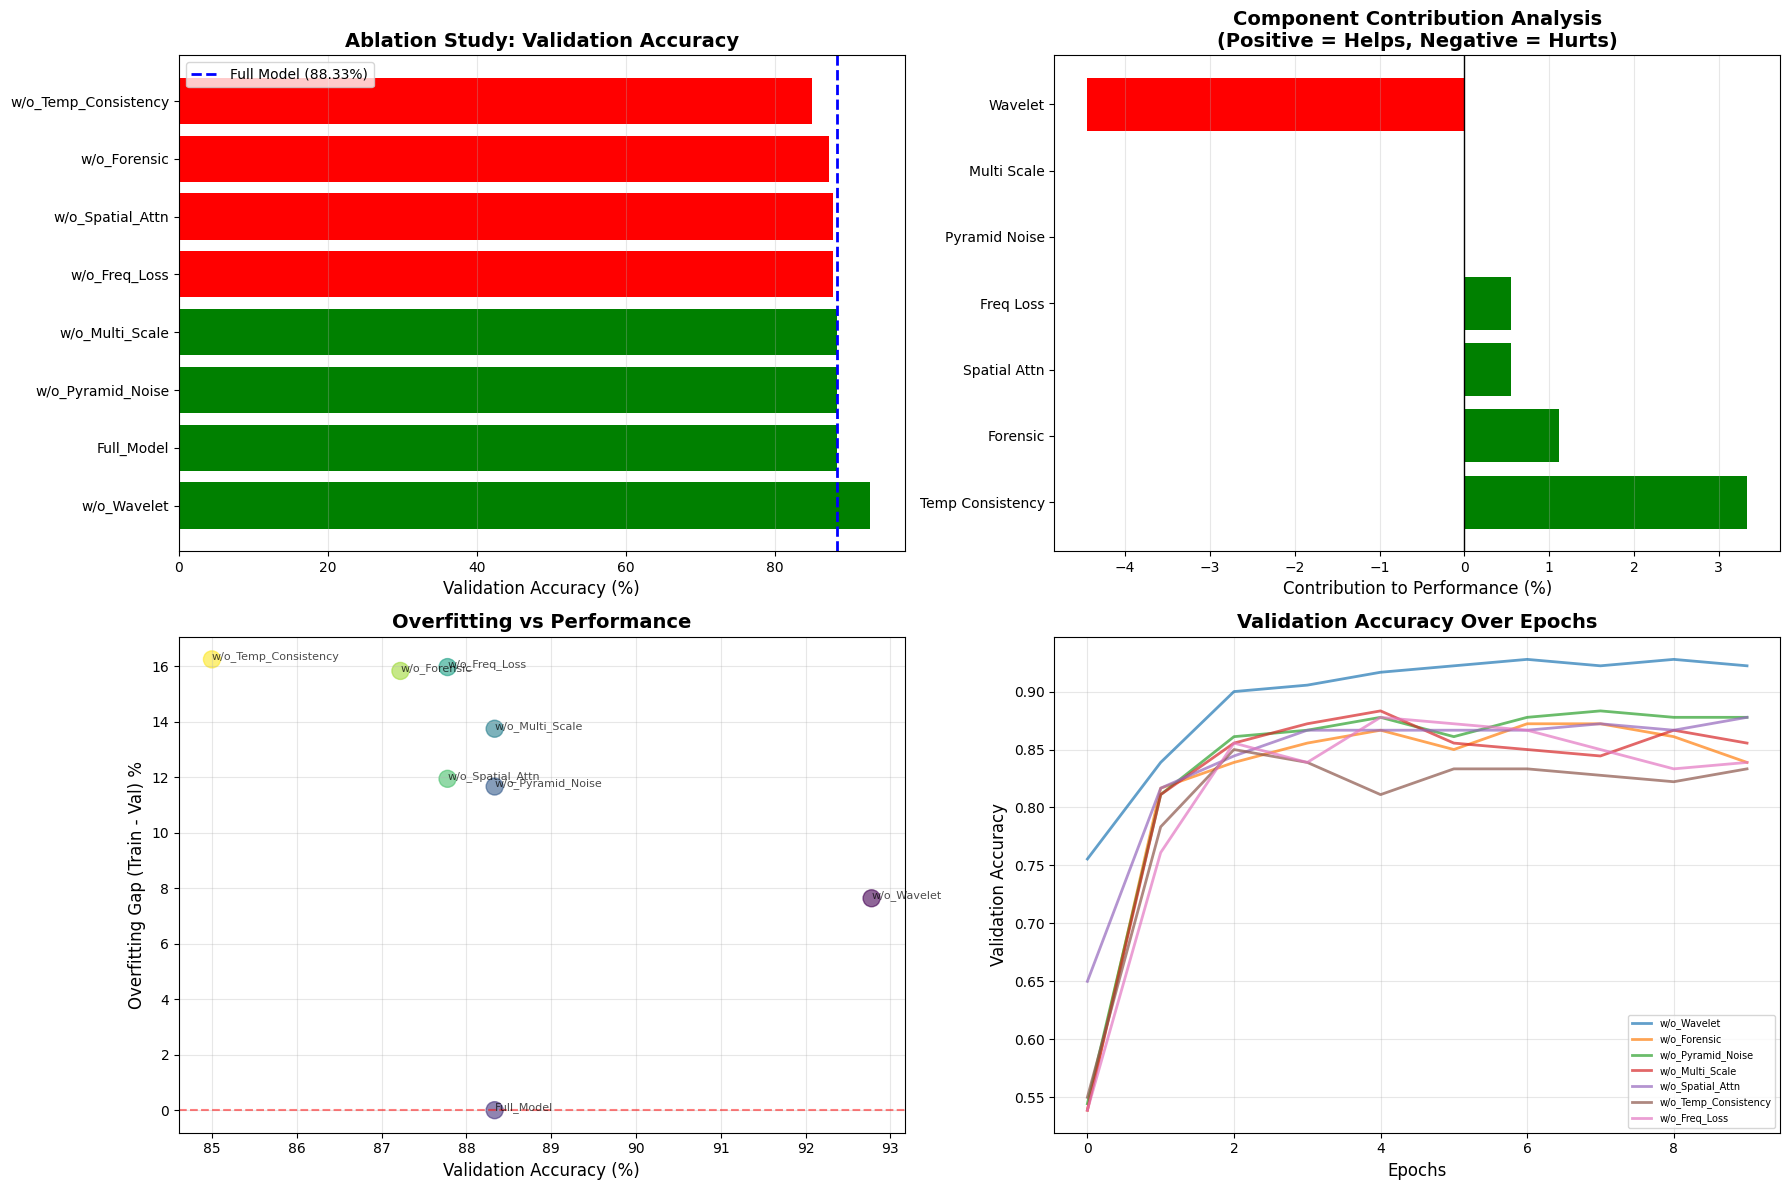


Ablation study plots saved to 'results/ablation_study.png'

RECOMMENDATIONS BASED ON ABLATION STUDY

✓ BEST CONFIGURATION: w/o_Wavelet
  Validation Accuracy: 92.78%
  Overfitting Gap: 7.64%

⚠ HARMFUL COMPONENTS (remove these):
  - Wavelet: -4.44% (makes model worse)

✓ HELPFUL COMPONENTS (keep these):
  + Temp Consistency: +3.33% improvement
  + Forensic: +1.11% improvement
  + Spatial Attn: +0.56% improvement
  + Freq Loss: +0.56% improvement



In [ ]:
# ============================================================================
# ABLATION STUDY
# ============================================================================

print("\n" + "="*70)
print("STARTING ABLATION STUDY")
print("Testing which components contribute to performance")
print("="*70)

# Get all ablation configurations
ablation_configs = ExperimentConfig.get_ablation_configs()

ablation_results = {}

for abl_name, config in ablation_configs.items():
    safe_name = abl_name.replace('/', '_').replace('\\', '_')
    model_path = f"models/ablation_{safe_name}.pth"
    
    # Check if model already exists
    if os.path.exists(model_path):
        print("\n" + "="*70)
        print(f"SKIPPING: {abl_name} (model already exists)")
        print(f"Loading results from: {model_path}")
        print("="*70)
        
        checkpoint = torch.load(model_path, map_location=device)
        
        ablation_results[abl_name] = {
            'config': config,
            'best_val_acc': checkpoint['val_acc'],
            'train_losses': checkpoint.get('train_losses', []),
            'val_losses': checkpoint.get('val_losses', []),
            'train_accs': checkpoint.get('train_accs', []),
            'val_accs': checkpoint.get('val_accs', []),
            'overfitting_gap': checkpoint.get('train_accs', [0])[-1] - checkpoint['val_acc'] if checkpoint.get('train_accs') else 0
        }
        
        print(f"Loaded: Best Val Acc = {checkpoint['val_acc']*100:.2f}%")
        continue
    
    print("\n" + "="*70)
    print(f"ABLATION: {abl_name}")
    print(f"Config: {config}")
    print("="*70)
    
    try:
        # Create datasets
        train_dataset = FakeVideoDataset(
            video_paths=train_paths,
            labels=train_labels,
            real_video_paths=real_paths,
            num_frames=NUM_FRAMES,
            is_train=True,
            config=config
        )
        
        val_dataset = FakeVideoDataset(
            video_paths=val_paths,
            labels=val_labels,
            real_video_paths=None,
            num_frames=NUM_FRAMES,
            is_train=False,
            config=config
        )
        
        train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
        val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)
        
        # Create model
        model = Detector3DViT(
            pretrained=True,
            use_advanced_features=config['use_advanced_features'],
            model_name=config['model_name']
        ).to(device)
        
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model.head.parameters(), lr=1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=2, verbose=True
        )
        
        # Training (shorter for ablation)
        NUM_EPOCHS = 10
        best_val_acc = 0.0
        train_losses, val_losses = [], []
        train_accs, val_accs = [], []
        
        for epoch in range(NUM_EPOCHS):
            print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
            
            t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, config)
            v_loss, v_acc = validate(model, val_loader, criterion)
            
            scheduler.step(v_acc)
            
            train_losses.append(t_loss)
            val_losses.append(v_loss)
            train_accs.append(t_acc)
            val_accs.append(v_acc)
            
            print(f"Train Loss: {t_loss:.4f} | Train Acc: {t_acc*100:.2f}%")
            print(f"Val Loss:   {v_loss:.4f} | Val Acc:   {v_acc*100:.2f}%")
            
            if v_acc > best_val_acc:
                best_val_acc = v_acc
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'config': config,
                    'val_acc': v_acc,
                    'train_losses': train_losses,
                    'val_losses': val_losses,
                    'train_accs': train_accs,
                    'val_accs': val_accs
                }, model_path)
                print(f"Best model saved: {v_acc*100:.2f}%")
        
        # Save results
        ablation_results[abl_name] = {
            'config': config,
            'best_val_acc': best_val_acc,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accs': train_accs,
            'val_accs': val_accs,
            'overfitting_gap': train_accs[-1] - val_accs[-1]
        }
        
        print(f"\n{abl_name} COMPLETED - Best Val Acc: {best_val_acc*100:.2f}%")
        
    except Exception as e:
        print(f"ERROR in {abl_name}: {str(e)}")
        import traceback
        traceback.print_exc()
        continue

# Save ablation results
with open('results/ablation_study.json', 'w') as f:
    json.dump({k: {**v, 'config': str(v['config'])} for k, v in ablation_results.items()}, f, indent=2)

print("\n" + "="*70)
print("ABLATION STUDY COMPLETED!")
print("="*70)

# ============================================================================
# ABLATION ANALYSIS
# ============================================================================

import pandas as pd

print("\n" + "="*70)
print("ABLATION STUDY RESULTS")
print("="*70)

# Create detailed comparison table
ablation_data = []
for abl_name, results in ablation_results.items():
    cfg = results['config']
    ablation_data.append({
        'Experiment': abl_name,
        'Val Acc (%)': results['best_val_acc'] * 100,
        'Train Acc (%)': results['train_accs'][-1] * 100 if results['train_accs'] else 0,
        'Overfitting Gap (%)': results['overfitting_gap'] * 100,
        'Wavelet': cfg['augmentations'].get('wavelet', False),
        'Forensic': cfg['augmentations'].get('forensic', False),
        'Pyramid': cfg['augmentations'].get('pyramid_noise', False),
        'Multi-Scale': cfg['augmentations'].get('multi_scale_temporal', False),
        'Spatial Attn': cfg['use_advanced_features'],
        'Temp Loss': cfg['loss'].get('temporal_consistency', False),
        'Freq Loss': cfg['loss'].get('frequency_domain', False)
    })

df_ablation = pd.DataFrame(ablation_data)
df_ablation = df_ablation.sort_values('Val Acc (%)', ascending=False)

print(df_ablation.to_string(index=False))

# Calculate contribution of each component
full_model_acc = df_ablation[df_ablation['Experiment'] == 'Full_Model']['Val Acc (%)'].values[0]

print("\n" + "="*70)
print("COMPONENT CONTRIBUTION ANALYSIS")
print("="*70)

contributions = []
for _, row in df_ablation.iterrows():
    if row['Experiment'] != 'Full_Model':
        # Contribution = (Full Model Acc) - (Model without component Acc)
        # Positive = component helps, Negative = component hurts
        contribution = full_model_acc - row['Val Acc (%)']
        component_name = row['Experiment'].replace('w/o_', '').replace('_', ' ')
        contributions.append({
            'Component': component_name,
            'Contribution (%)': contribution,
            'Status': 'HELPS' if contribution > 0 else 'HURTS'
        })

df_contrib = pd.DataFrame(contributions).sort_values('Contribution (%)', ascending=False)
print(df_contrib.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Ablation Results Bar Chart
axes[0, 0].barh(df_ablation['Experiment'], df_ablation['Val Acc (%)'], 
                color=['green' if acc >= full_model_acc else 'red' 
                       for acc in df_ablation['Val Acc (%)']])
axes[0, 0].axvline(x=full_model_acc, color='blue', linestyle='--', 
                   linewidth=2, label=f'Full Model ({full_model_acc:.2f}%)')
axes[0, 0].set_xlabel('Validation Accuracy (%)', fontsize=12)
axes[0, 0].set_title('Ablation Study: Validation Accuracy', fontweight='bold', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: Component Contribution
colors = ['green' if c > 0 else 'red' for c in df_contrib['Contribution (%)']]
axes[0, 1].barh(df_contrib['Component'], df_contrib['Contribution (%)'], color=colors)
axes[0, 1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0, 1].set_xlabel('Contribution to Performance (%)', fontsize=12)
axes[0, 1].set_title('Component Contribution Analysis\n(Positive = Helps, Negative = Hurts)', 
                     fontweight='bold', fontsize=14)
axes[0, 1].grid(axis='x', alpha=0.3)

# Plot 3: Overfitting Analysis
axes[1, 0].scatter(df_ablation['Val Acc (%)'], df_ablation['Overfitting Gap (%)'], 
                   s=150, alpha=0.6, c=range(len(df_ablation)), cmap='viridis')
for idx, row in df_ablation.iterrows():
    axes[1, 0].annotate(row['Experiment'], 
                       (row['Val Acc (%)'], row['Overfitting Gap (%)']),
                       fontsize=8, alpha=0.7)
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Validation Accuracy (%)', fontsize=12)
axes[1, 0].set_ylabel('Overfitting Gap (Train - Val) %', fontsize=12)
axes[1, 0].set_title('Overfitting vs Performance', fontweight='bold', fontsize=14)
axes[1, 0].grid(alpha=0.3)

# Plot 4: Training Curves Comparison
for abl_name, results in ablation_results.items():
    if results['val_accs']:  # Solo se ci sono dati
        axes[1, 1].plot(results['val_accs'], label=abl_name, linewidth=2, alpha=0.7)
axes[1, 1].set_xlabel('Epochs', fontsize=12)
axes[1, 1].set_ylabel('Validation Accuracy', fontsize=12)
axes[1, 1].set_title('Validation Accuracy Over Epochs', fontweight='bold', fontsize=14)
axes[1, 1].legend(fontsize=7, loc='best')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAblation study plots saved to 'results/ablation_study.png'")

# ============================================================================
# FINAL RECOMMENDATIONS
# ============================================================================

print("\n" + "="*70)
print("RECOMMENDATIONS BASED ON ABLATION STUDY")
print("="*70)

# Find best configuration
best_config = df_ablation.iloc[0]
print(f"\n✓ BEST CONFIGURATION: {best_config['Experiment']}")
print(f"  Validation Accuracy: {best_config['Val Acc (%)']:.2f}%")
print(f"  Overfitting Gap: {best_config['Overfitting Gap (%)']:.2f}%")

# Identify harmful components
harmful = df_contrib[df_contrib['Contribution (%)'] < 0]
if len(harmful) > 0:
    print("\n⚠ HARMFUL COMPONENTS (remove these):")
    for _, comp in harmful.iterrows():
        print(f"  - {comp['Component']}: {comp['Contribution (%)']:.2f}% (makes model worse)")

# Identify helpful components
helpful = df_contrib[df_contrib['Contribution (%)'] > 0]
if len(helpful) > 0:
    print("\n✓ HELPFUL COMPONENTS (keep these):")
    for _, comp in helpful.iterrows():
        print(f"  + {comp['Component']}: +{comp['Contribution (%)']:.2f}% improvement")

print("\n" + "="*70)